# AOI: Purchase, NY

## Train AI Model for Building Detection
- This task is called 'semantic segmentation' in AI context
- Use models from `segmentation-models-pytorch` library (https://smp.readthedocs.io)

## Setup & Import
GPU & GeoAI wrapper tool is require

In [3]:
# GPU is required - T4 GPU will be used
!nvidia-smi

Mon May  4 22:33:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# GeoAI = wrapper tool
%pip install geoai-py

  Using cached geoai_py-0.37.2-py2.py3-none-any.whl.metadata (13 kB)
  Using cached contextily-1.7.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached jupyter_server_proxy-4.5.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached leafmap-0.62.0-py2.py3-none-any.whl.metadata (17 kB)
  Using cached localtileserver-1.0.0-py3-none-any.whl.metadata (10 kB)
  Using cached maplibre-0.3.6-py3-none-any.whl.metadata (4.2 kB)
  Using cached overturemaps-1.0.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached planetary_computer-1.0.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached pystac_client-0.9.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached rioxarray-0.22.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached smoothify-0.2.2-py3-none-any.whl.metadata (9.5 kB)
  Using cached torchgeo-0.9.0-py3-none-any.whl.metadata (19 kB)
  Using cached torchinfo-1.8.0-py3-none-any.whl.metadata (21 kB)
  Using cached duckdb-1.5.2-cp312-cp312-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl.metadata (4.2 kB)
 

In [5]:
import geoai
geoai.__version__

'0.37.2'

## Data Import

In [6]:
train_raster_path = "/content/merged_clipped-1.tif"
train_vector_path = "/content/filename.geojson"

### Create training data (image chips)

In [7]:
out_folder = "buildings"
tiles = geoai.export_geotiff_tiles(
    in_raster = train_raster_path, # satellite
    out_folder = out_folder, # folder containing image chips
    in_class_data = train_vector_path, # label
    tile_size = 512, # size of chips (width, height in px)
    stride = 256,
    buffer_radius = 0
)

Generated: 4, With features: 4: 100%|██████████| 4/4 [00:00<00:00, 11.00it/s]


## SegFormer

### Model Training:

In [8]:
# function train_segmentation_model is required to train segmentation model
geoai.train_segmentation_model(
    images_dir = f"{out_folder}/images", # location for input image data
    labels_dir = f"{out_folder}/labels", # location for input label data
    output_dir = f"{out_folder}/seg_former_models", # location for storing trained model's spec/log
    architecture = "segformer", # segmentation model
    encodder_name = "mit_b0", # encoder model,
    encoder_weights = "imagenet",
    num_channels = 3, # RGB
    num_classes = 2, # building vs non-building
    batch_size = 4,
    num_epochs = 20,
    learning_rate = 0.001,
    val_split = 0.2,
    verbose = True
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

### Inference (Prediction)

In [9]:
masks_path = "naip_test_semantic_prediction.tif"
model_path = f"{out_folder}/seg_former_models/best_model.pth"

In [10]:
#SegFormer Model Training
geoai.semantic_segmentation(
    input_path = train_raster_path,
    output_path = masks_path,
    model_path = model_path,
    architecture = "segformer", # segmentation model
    encodder_name = "mit_b3", # encoder model,
    num_channels = 3, # RGB
    num_classes = 2, # building vs non-building
    window_size = 512,
    stride = 256,
    batch_size = 4,
)

9it [00:00, 44.44it/s]


In [11]:
# Visualize
geoai.view_raster(masks_path, basemap=train_raster_path, backend="ipyleaflet")

Map(center=[41.0376135, -73.73818800000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_…

### Vectorize masks (output labels)

In [12]:
output_vector_path = "naip_test_semantic_prediction.geojson"
gdf = geoai.orthogonalize(masks_path, output_vector_path, epsilon=2) # smoothes of polygon borders
gdf

Converting features: 100%|██████████| 49/49 [00:01<00:00, 40.35shape/s]


,geometry,value
0,"POLYGON ((606244.754 4543858.071, 606244.754 4...",1
1,"POLYGON ((605944.154 4543858.071, 605944.154 4...",1
2,"POLYGON ((606154.754 4543858.071, 606154.754 4...",1
3,"POLYGON ((606259.754 4543851.471, 606259.754 4...",1
4,"POLYGON ((606259.154 4543847.871, 606259.154 4...",1
5,"POLYGON ((606170.954 4543847.871, 606170.954 4...",1
6,"POLYGON ((606028.154 4543836.471, 606028.154 4...",1
7,"POLYGON ((606054.554 4543833.471, 606054.554 4...",1
8,"POLYGON ((605995.154 4543846.071, 605995.154 4...",1
9,"POLYGON ((605953.154 4543831.671, 605953.154 4...",1


### Performance Analysis

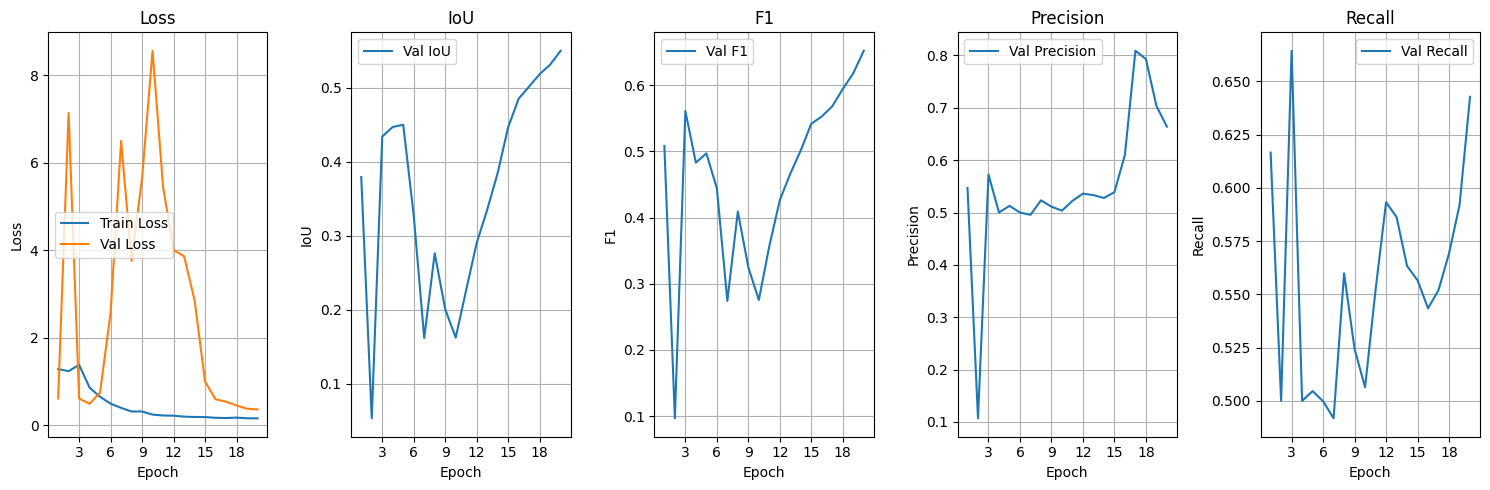

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,1.286362,0.613139,0.379489,0.508175,0.547026,0.616580
1,2,1.237539,7.140954,0.053423,0.096532,0.106846,0.500000
2,3,1.383090,0.611461,0.434249,0.561038,0.572514,0.664425
3,4,0.859630,0.490077,0.447222,0.482981,0.500045,0.500008
4,5,0.651285,0.755079,0.450111,0.497060,0.512708,0.504587
5,6,0.493491,2.572673,0.327615,0.444456,0.499934,0.499835
6,7,0.398295,6.502359,0.161928,0.274032,0.495594,0.491805
7,8,0.315484,3.761080,0.276427,0.409127,0.523220,0.559881
8,9,0.315359,5.658382,0.200878,0.324802,0.511156,0.524367
9,10,0.244310,8.565971,0.162544,0.275458,0.503497,0.506369


In [13]:
geoai.plot_performance_metrics (
    history_path = f"{out_folder}/seg_former_models/training_history.pth",
    figsize=(15, 5),
    verbose = True
)

#Qualitative Comparison

In [14]:
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import numpy as np
import matplotlib.pyplot as plt

# File paths
ground_truth_vector_path = "filename.geojson"
predicted_mask_path = "naip_test_semantic_prediction.tif"

In [15]:
# Open predicted raster
with rasterio.open(predicted_mask_path) as src:
    prediction = src.read(1)
    transform = src.transform
    raster_crs = src.crs
    raster_shape = src.shape

In [16]:
# Read ground truth GeoJSON
gdf = gpd.read_file(ground_truth_vector_path)

# Match CRS between GeoJSON and raster
if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

# Convert GeoJSON polygons into raster labels
ground_truth = rasterize(
    [(geom, 1) for geom in gdf.geometry],
    out_shape=raster_shape,
    transform=transform,
    fill=0,
    dtype="uint8"
)

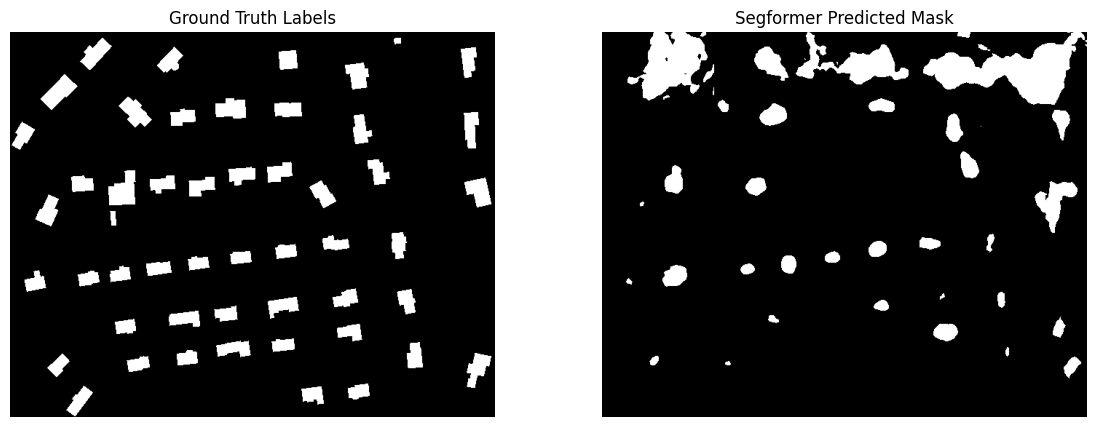

In [17]:
# Make predicted mask binary
prediction_binary = (prediction == 1).astype("uint8")

# Plot qualitative comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth Labels")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(prediction_binary, cmap="gray")
plt.title("Segformer Predicted Mask")
plt.axis("off")

plt.show()